In [1]:
# EXPERIMENTO 3 (OBSERVACIONAL): barrido de beta sobre los 11 datasets sinteticos del benchmark.
# Mismo protocolo que el Experimento 1, pero cambiando el SCM triangulo hecho a mano por los datasets
# de src/datasets/synthetic.py (la misma lista que usa notebooks/alejandro/paper_plots.ipynb).
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))

import time
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.metrics import mmd, rf
from src.models.kan import kan_model_mixed
from src.datasets.synthetic import graph_data


# --- [PASO 1: FUNCIONES AUXILIARES] ---

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuracion de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()

def clave_run(dataset, seed, n, beta):
    """Identificador de un run. Sirve para no reentrenar lo que ya esta en el CSV."""
    return (str(dataset), int(seed), int(n), round(float(beta), 5))


# --- [PASO 2: CONFIGURACION DEL EXPERIMENTO] ---

# Los 11 datasets del benchmark continuo del paper (misma lista que paper_plots.ipynb).
datasets_evaluados = ['3-chain-linear', '3-chain-non-linear', '4-chain-linear', '5-chain-linear',
                      'collider-linear', 'fork-linear', 'fork-non-linear', 'simpson-non-linear',
                      'simpson-symprod', 'triangle-linear', 'triangle-non-linear']

# N_actual es el tamano del conjunto de ENTRENAMIENTO; la evaluacion siempre usa 100 muestras fijas.
valores_N_experimento = [50, 100]
# Barrido completo de beta. Los que ya esten en el CSV NO se reentrenan (ver reanudacion mas abajo).
valores_beta_candidatos = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
semillas_experimento = np.arange(42, 52)  # 10 semillas (42-51)

# Conjunto de evaluacion FIJO por dataset: todas las semillas, N y betas se evaluan siempre contra las
# mismas 100 muestras, generadas una unica vez con una semilla propia.
N_EVAL_FIJO = 100
SEED_EVAL_FIJO = 9999

# Metricas de este experimento (observacionales).
metricas_experimento = ['RF Acc', 'MMD', 'MAE x3']

base_cols = ['Dataset', 'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}


# --- [PASO 2b: REANUDACION - no se reentrena nada que ya este en el CSV] ---
# Los KANs no se guardan en disco: lo que se conserva son las filas de metricas ya calculadas. Al
# releerlas, cualquier combinacion (Dataset, Seed, N, Beta) que ya exista se omite, de modo que
# anadir betas nuevos solo entrena los betas nuevos.
carpeta_tablas = "tablas"
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)
ruta_archivo = os.path.join(carpeta_tablas, "datasets_sinteticos_observacional.csv")

if os.path.exists(ruta_archivo):
    df_previo = pd.read_csv(ruta_archivo)
    runs_hechos = {clave_run(r.Dataset, r.Seed, r.N, r.Beta) for r in df_previo.itertuples(index=False)}
    print(f"Reanudando desde {ruta_archivo}: {len(df_previo)} runs ya calculados "
          f"(betas {sorted(df_previo['Beta'].unique())}) -> no se reentrenan.")
else:
    df_previo = pd.DataFrame()
    runs_hechos = set()
    print("No hay CSV previo: se entrena el barrido completo desde cero.")

registros_tabla_final = []
t_inicio_global = time.time()

total_runs = len(datasets_evaluados) * len(semillas_experimento) * len(valores_N_experimento) * len(valores_beta_candidatos)
runs_pendientes = sum(1 for d in datasets_evaluados for s in semillas_experimento
                      for n in valores_N_experimento for b in valores_beta_candidatos
                      if clave_run(d, s, n, b) not in runs_hechos)
print(f"Rejilla completa: {total_runs} runs "
      f"({len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas x {len(valores_N_experimento)} N x {len(valores_beta_candidatos)} betas)")
print(f"Pendientes de entrenar: {runs_pendientes}")


def guardar_checkpoint():
    """Vuelca a CSV lo previo + lo nuevo. Permite interrumpir y reanudar sin perder trabajo."""
    if not registros_tabla_final:
        return
    df_ckpt = pd.concat([df_previo, pd.DataFrame(registros_tabla_final)], ignore_index=True)
    df_ckpt = df_ckpt[base_cols + metricas_experimento].sort_values(by=['Dataset', 'N', 'Beta', 'Seed'])
    df_ckpt.to_csv(ruta_archivo, index=False)


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACION] ---

for dataset in datasets_evaluados:
    print("\n" + "#"*70)
    print(f"DATASET: {dataset}")
    print("#"*70)

    # graph_data(...).generate devuelve (data, data_cf, graph, formula); aqui solo se usan data y graph.
    factual_eval_d, _, graph_ds, _ = graph_data(name=dataset).generate(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO)
    # El orden de graph_ds.nodes NO coincide con el de las columnas en collider/fork: usar var_names.
    var_names = list(factual_eval_d.columns)
    datos_reales_test = factual_eval_d[var_names].to_numpy()
    num_muestras_eval = len(factual_eval_d)

    node_types = {nodo: 'continuous' for nodo in graph_ds.nodes}
    num_classes = {}

    print(f"  Nodos: {var_names} | Aristas: {list(graph_ds.edges)}")

    for experiment_id, seed in enumerate(semillas_experimento, start=1):
        for N_actual in valores_N_experimento:
            factual_train_d, _, _, _ = graph_data(name=dataset).generate(num_samples=N_actual, seed=int(seed))

            for beta_val in valores_beta_candidatos:
                # Ya calculado en una ejecucion anterior: se conserva su fila del CSV y no se reentrena.
                if clave_run(dataset, seed, N_actual, beta_val) in runs_hechos:
                    continue

                # Misma convencion que el Experimento 1: beta=0 es MSE puro, beta>0 es hibrido con alpha=1-beta.
                if beta_val == 0.0:
                    strategy_name, alpha_val = "mse", 1.0
                else:
                    strategy_name, alpha_val = "hybrid", round(1.0 - beta_val, 2)

                params_estructurados = crear_estructura_nodos(
                    graph_ds, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
                )

                print(f" -> {dataset} | semilla={seed} | N={N_actual} | beta={beta_val} ({strategy_name.upper()})")
                model = kan_model_mixed(graph_ds, params_estructurados)
                model.fit(data=factual_train_d)

                conf_name = "MSE" if strategy_name == "mse" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
                fila = {
                    'Dataset': dataset,
                    'Experiment': experiment_id,
                    'Seed': int(seed),
                    'Loss': strategy_name,
                    'Conf': conf_name,
                    'Alpha': alpha_val,
                    'Beta': beta_val,
                    'N': N_actual
                }

                try:
                    # MAE x3: error absoluto medio del residuo de la ecuacion estructural de x3 (analogo al MAE Z del Exp. 1).
                    residuos = model.get_residuals(factual_eval_d)
                    r_x3 = preparar_residuo(residuos['x3'])
                    fila['MAE x3'] = round(float(np.mean(np.abs(r_x3))), 5)

                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[var_names].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

                except Exception as e:
                    print(f"   [Error en evaluacion] {dataset} | {conf_name} | N={N_actual} | semilla={seed}: {e}")

                registros_tabla_final.append(fila)

    # Checkpoint tras cada dataset: si se interrumpe la ejecucion, al relanzarla se reanuda aqui.
    guardar_checkpoint()


# --- [PASO 4: TABLA MAESTRA] ---
# Lo ya calculado (df_previo) + lo entrenado en esta ejecucion (registros_tabla_final).
df_nuevos = pd.DataFrame(registros_tabla_final)
df_final = pd.concat([df_previo, df_nuevos], ignore_index=True) if len(df_previo) else df_nuevos
df_final = df_final[base_cols + metricas_experimento]
df_final = df_final.sort_values(by=['Dataset', 'N', 'Beta', 'Seed']).reset_index(drop=True)

print(f"\n--- MATRIZ DE DIAGNOSTICO FINALIZADA ---")
print(f"    {len(df_final)} runs en total | {len(df_nuevos)} entrenados ahora "
      f"| {len(df_previo)} reutilizados | {time.time() - t_inicio_global:.0f} s")
display(df_final)

# --- [PASO 5: GUARDADO EN CSV] ---
df_final.to_csv(ruta_archivo, index=False)
print(f"Tabla maestra guardada en: {ruta_archivo}")

No hay CSV previo: se entrena el barrido completo desde cero.
Rejilla completa: 1980 runs (11 datasets x 10 semillas x 2 N x 9 betas)
Pendientes de entrenar: 1980

######################################################################
DATASET: 3-chain-linear
######################################################################
  Nodos: ['x1', 'x2', 'x3'] | Aristas: [('x1', 'x2'), ('x2', 'x3')]
 -> 3-chain-linear | semilla=42 | N=50 | beta=0.0 (MSE)
Using device: cpu
Early stopping at step 279
Using device: cpu
Early stopping at step 61
 -> 3-chain-linear | semilla=42 | N=50 | beta=0.1 (HYBRID)
Using device: cpu
Early stopping at step 423
Using device: cpu
Early stopping at step 51
 -> 3-chain-linear | semilla=42 | N=50 | beta=0.2 (HYBRID)
Using device: cpu
Early stopping at step 318
Using device: cpu
Early stopping at step 113
 -> 3-chain-linear | semilla=42 | N=50 | beta=0.3 (HYBRID)
Using device: cpu
Early stopping at step 349
Using device: cpu
Early stopping at step 120
 -> 3-chain

,Dataset,Experiment,Seed,Loss,Conf,Alpha,Beta,N,RF Acc,MMD,MAE x3
0,3-chain-linear,1,42,mse,MSE,1.0,0.0,50,0.675,0.01648,0.81913
1,3-chain-linear,2,43,mse,MSE,1.0,0.0,50,0.625,0.01878,0.85148
2,3-chain-linear,3,44,mse,MSE,1.0,0.0,50,0.525,0.01410,0.84352
3,3-chain-linear,4,45,mse,MSE,1.0,0.0,50,0.750,0.03863,0.88809
4,3-chain-linear,5,46,mse,MSE,1.0,0.0,50,0.500,0.01382,0.83991
...,...,...,...,...,...,...,...,...,...,...,...
1975,triangle-non-linear,6,47,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,0.750,0.02261,0.68351
1976,triangle-non-linear,7,48,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,0.625,0.01107,0.24716
1977,triangle-non-linear,8,49,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,0.675,0.01929,0.40826
1978,triangle-non-linear,9,50,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,0.750,0.01907,0.53724


Tabla maestra guardada en: tablas/datasets_sinteticos_observacional.csv


In [2]:
# PASO 6: resumen media +/- std sobre las 10 semillas, para cada combinacion (Dataset, N, Beta).
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA +/- DESVIACION TIPICA POR DATASET, N Y BETA")
print("="*100)

resumen_por_dataset = []
for (dataset, n_val, beta_val), grupo in df_final.groupby(['Dataset', 'N', 'Beta']):
    fila_resumen = {
        'Dataset': dataset,
        'N': n_val,
        'Beta': beta_val,
        'Alpha': grupo['Alpha'].iloc[0],
        'Loss': grupo['Loss'].iloc[0],
        'Num_Seeds': len(grupo)
    }
    for metrica in metricas_experimento:
        fila_resumen[f'{metrica}_mean'] = round(float(grupo[metrica].mean()), 5)
        fila_resumen[f'{metrica}_std'] = round(float(grupo[metrica].std()), 5)
    resumen_por_dataset.append(fila_resumen)

df_resumen = pd.DataFrame(resumen_por_dataset).sort_values(['Dataset', 'N', 'Beta']).reset_index(drop=True)
display(df_resumen)

ruta_resumen = os.path.join("tablas", "resumen_por_dataset_observacional.csv")
df_resumen.to_csv(ruta_resumen, index=False)
print(f"\nTabla resumen guardada en: {ruta_resumen}")

# Version legible "media +/- std", un bloque por (dataset, N).
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media +/- Std por dataset y N")
print(f"{'='*100}")
for dataset in datasets_evaluados:
    for n_val in valores_N_experimento:
        df_ds = df_resumen[(df_resumen['Dataset'] == dataset) & (df_resumen['N'] == n_val)]
        if df_ds.empty:
            continue
        tabla_legible = {}
        for _, r in df_ds.iterrows():
            tabla_legible[f"Beta={r['Beta']}"] = [f"{r[f'{m}_mean']:.5f} +/- {r[f'{m}_std']:.5f}" for m in metricas_experimento]
        print(f"\n{'-'*100}\n{dataset}  |  N = {n_val}\n{'-'*100}")
        display(pd.DataFrame(tabla_legible, index=metricas_experimento))


TABLA RESUMEN: MEDIA +/- DESVIACION TIPICA POR DATASET, N Y BETA


,Dataset,N,Beta,Alpha,Loss,Num_Seeds,RF Acc_mean,RF Acc_std,MMD_mean,MMD_std,MAE x3_mean,MAE x3_std
0,3-chain-linear,50,0.0,1.0,mse,10,0.6375,0.08354,0.01881,0.00893,0.86318,0.04303
1,3-chain-linear,50,0.1,0.9,hybrid,10,0.6225,0.08203,0.01791,0.00926,0.86411,0.04385
2,3-chain-linear,50,0.2,0.8,hybrid,10,0.6275,0.09821,0.01647,0.00791,0.85472,0.04416
3,3-chain-linear,50,0.3,0.7,hybrid,10,0.6300,0.08563,0.01565,0.00672,0.85179,0.03938
4,3-chain-linear,50,0.4,0.6,hybrid,10,0.6600,0.07091,0.01687,0.00730,0.86075,0.06593
...,...,...,...,...,...,...,...,...,...,...,...,...
193,triangle-non-linear,100,0.4,0.6,hybrid,10,0.6525,0.08616,0.01558,0.00397,0.32315,0.10741
194,triangle-non-linear,100,0.5,0.5,hybrid,10,0.6425,0.09432,0.01559,0.00406,0.32636,0.07451
195,triangle-non-linear,100,0.6,0.4,hybrid,10,0.6575,0.07997,0.01529,0.00338,0.30899,0.07367
196,triangle-non-linear,100,0.7,0.3,hybrid,10,0.6425,0.08420,0.01670,0.00503,0.38883,0.14768



Tabla resumen guardada en: tablas/resumen_por_dataset_observacional.csv


FORMATO LEGIBLE: Media +/- Std por dataset y N

----------------------------------------------------------------------------------------------------
3-chain-linear  |  N = 50
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.1,Beta=0.2,Beta=0.3,Beta=0.4,Beta=0.5,Beta=0.6,Beta=0.7,Beta=0.8
RF Acc,0.63750 +/- 0.08354,0.62250 +/- 0.08203,0.62750 +/- 0.09821,0.63000 +/- 0.08563,0.66000 +/- 0.07091,0.62500 +/- 0.09789,0.63250 +/- 0.07076,0.61250 +/- 0.08101,0.65000 +/- 0.08333
MMD,0.01881 +/- 0.00893,0.01791 +/- 0.00926,0.01647 +/- 0.00791,0.01565 +/- 0.00672,0.01687 +/- 0.00730,0.01614 +/- 0.00717,0.01603 +/- 0.00638,0.01618 +/- 0.00772,0.01555 +/- 0.00592
MAE x3,0.86318 +/- 0.04303,0.86411 +/- 0.04385,0.85472 +/- 0.04416,0.85179 +/- 0.03938,0.86075 +/- 0.06593,0.86011 +/- 0.05205,0.85432 +/- 0.04781,0.84325 +/- 0.01949,0.84027 +/- 0.01451



----------------------------------------------------------------------------------------------------
3-chain-linear  |  N = 100
----------------------------------------------------------------------------------------------------


...

,Beta=0.0,Beta=0.1,Beta=0.2,Beta=0.3,Beta=0.4,Beta=0.5,Beta=0.6,Beta=0.7,Beta=0.8
RF Acc,0.61250 +/- 0.06482,0.60250 +/- 0.07678,0.58750 +/- 0.06038,0.57500 +/- 0.06124,0.59250 +/- 0.09358,0.63500 +/- 0.07091,0.61750 +/- 0.06877,0.61750 +/- 0.06672,0.64750 +/- 0.06061
MMD,0.01273 +/- 0.00238,0.01171 +/- 0.00225,0.01214 +/- 0.00118,0.01090 +/- 0.00207,0.01046 +/- 0.00275,0.01208 +/- 0.00397,0.01146 +/- 0.00335,0.01091 +/- 0.00205,0.01223 +/- 0.00212
MAE x3,0.65703 +/- 0.26032,0.63317 +/- 0.21594,0.61044 +/- 0.19227,0.55219 +/- 0.15799,0.67911 +/- 0.50087,0.51882 +/- 0.05648,0.51944 +/- 0.04131,0.50253 +/- 0.03894,0.49568 +/- 0.02032



----------------------------------------------------------------------------------------------------
triangle-non-linear  |  N = 50
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.1,Beta=0.2,Beta=0.3,Beta=0.4,Beta=0.5,Beta=0.6,Beta=0.7,Beta=0.8
RF Acc,0.69500 +/- 0.05375,0.67250 +/- 0.07587,0.70250 +/- 0.08203,0.69750 +/- 0.08371,0.69750 +/- 0.06917,0.70250 +/- 0.07857,0.72000 +/- 0.04216,0.70250 +/- 0.05584,0.69500 +/- 0.05627
MMD,0.02936 +/- 0.01037,0.02769 +/- 0.01123,0.02686 +/- 0.01216,0.02702 +/- 0.01198,0.02690 +/- 0.01207,0.02631 +/- 0.01095,0.02896 +/- 0.01048,0.02486 +/- 0.00983,0.02770 +/- 0.00973
MAE x3,0.64871 +/- 0.35891,0.55502 +/- 0.18290,0.58792 +/- 0.18029,0.57996 +/- 0.18147,0.58486 +/- 0.17451,0.73249 +/- 0.23165,0.72563 +/- 0.22141,0.82732 +/- 0.30063,0.79707 +/- 0.24409



----------------------------------------------------------------------------------------------------
triangle-non-linear  |  N = 100
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.1,Beta=0.2,Beta=0.3,Beta=0.4,Beta=0.5,Beta=0.6,Beta=0.7,Beta=0.8
RF Acc,0.66250 +/- 0.07928,0.63500 +/- 0.06146,0.65000 +/- 0.07169,0.63500 +/- 0.06791,0.65250 +/- 0.08616,0.64250 +/- 0.09432,0.65750 +/- 0.07997,0.64250 +/- 0.08420,0.68000 +/- 0.07341
MMD,0.01760 +/- 0.00570,0.01668 +/- 0.00570,0.01607 +/- 0.00497,0.01558 +/- 0.00380,0.01558 +/- 0.00397,0.01559 +/- 0.00406,0.01529 +/- 0.00338,0.01670 +/- 0.00503,0.01833 +/- 0.00585
MAE x3,0.30245 +/- 0.07200,0.31261 +/- 0.08574,0.31723 +/- 0.09100,0.30961 +/- 0.08297,0.32315 +/- 0.10741,0.32636 +/- 0.07451,0.30899 +/- 0.07367,0.38883 +/- 0.14768,0.43760 +/- 0.19477



VISUALIZACION: MEDIA Y DESVIACION TIPICA POR METRICA
(Linea = Media sobre las 10 semillas | Area sombreada = Media +/- Std | Un color = un dataset)
(Una figura por cada N)

Grafica guardada: plots/bandplot_datasets_observacional_n_50.png



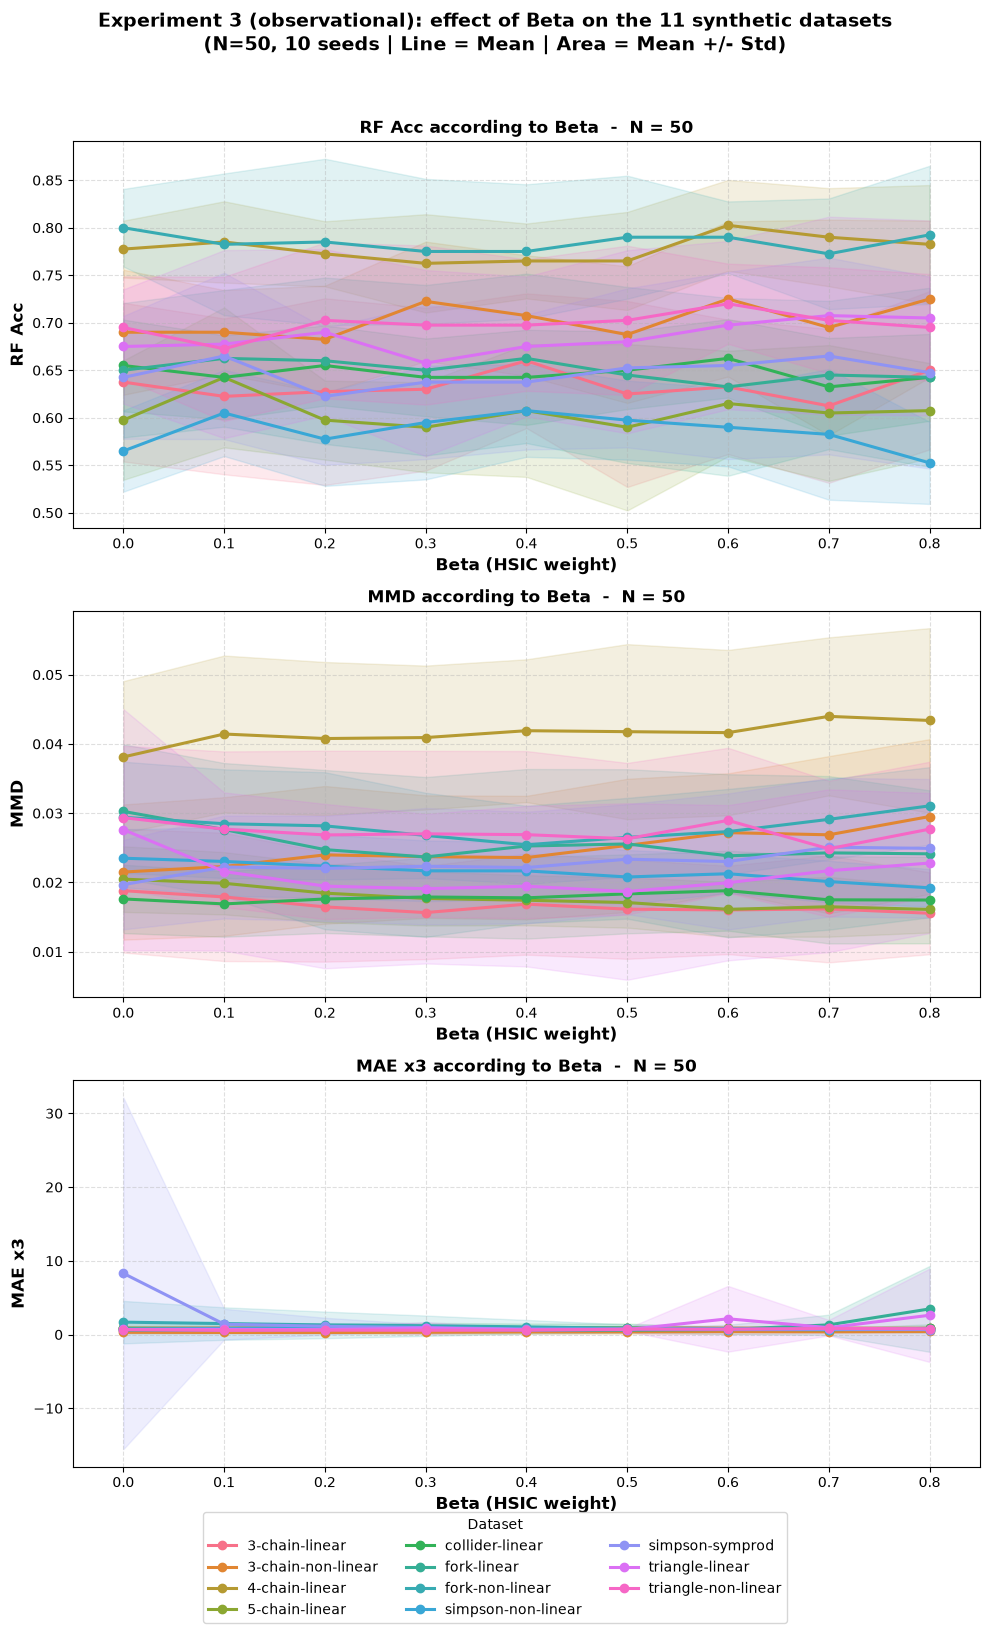

Grafica guardada: plots/bandplot_datasets_observacional_n_100.png



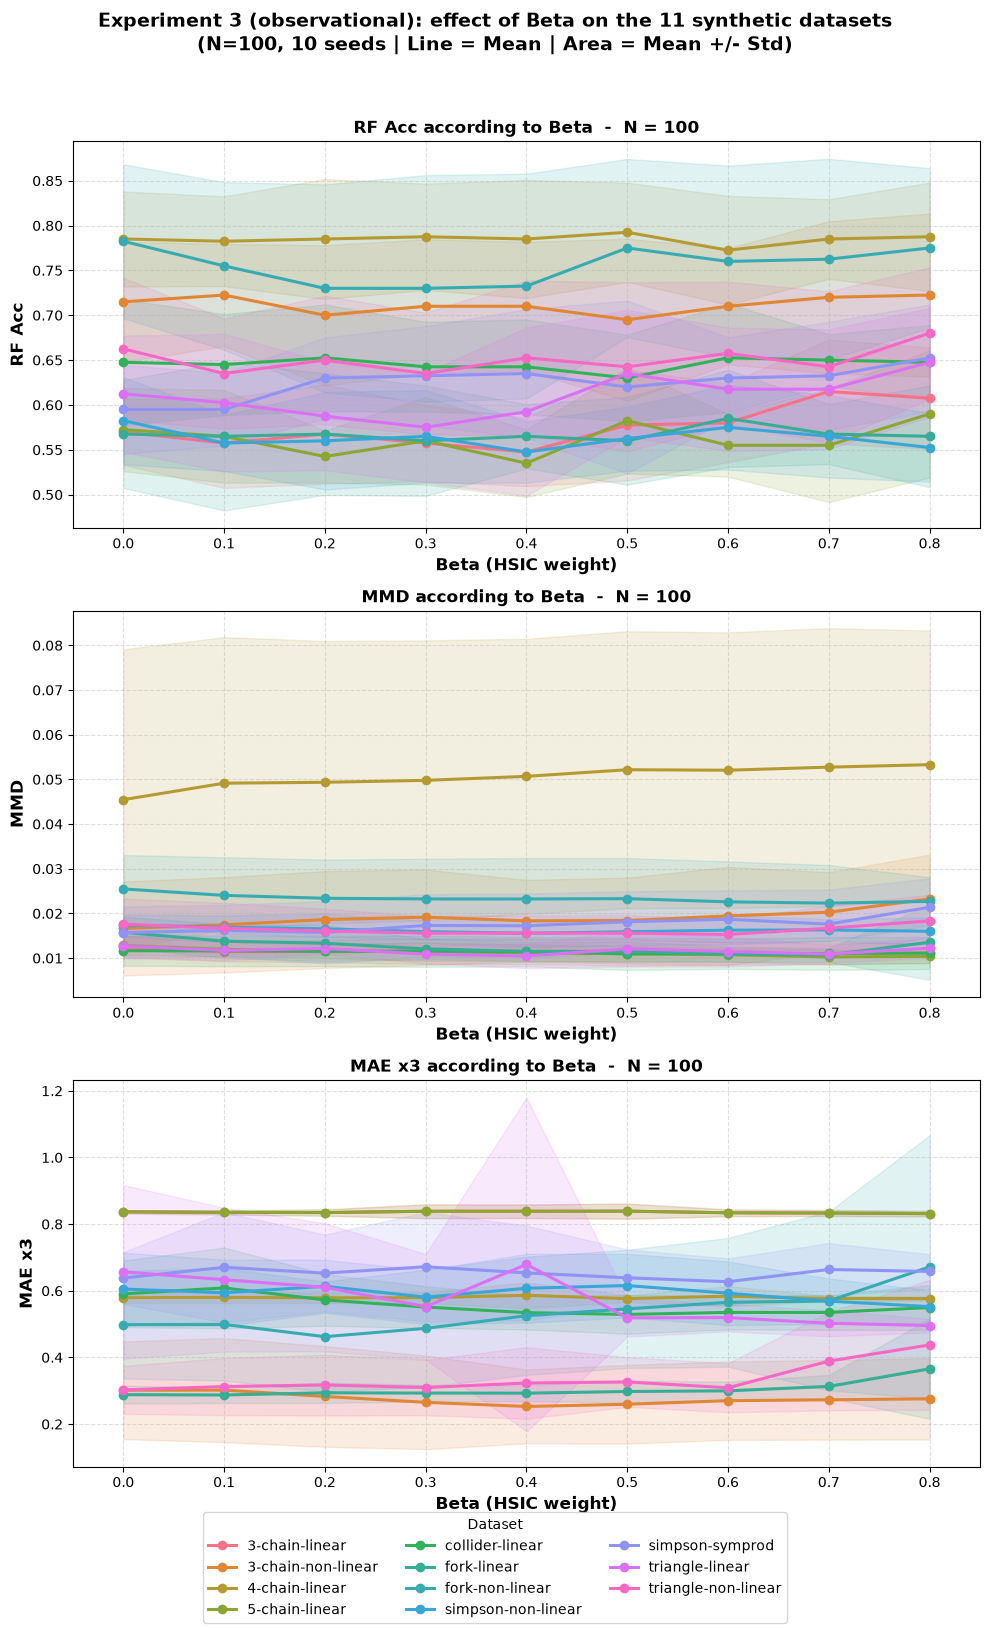

In [3]:
# PASO 7: una grafica por metrica (RF Acc, MMD, MAE x3). Eje X = beta, una curva por dataset,
# linea = media sobre las 10 semillas y banda sombreada = media +/- desviacion tipica.
# Una figura por cada N: mezclar los dos N en el mismo panel daria 22 curvas ilegibles.
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACION: MEDIA Y DESVIACION TIPICA POR METRICA")
print("(Linea = Media sobre las 10 semillas | Area sombreada = Media +/- Std | Un color = un dataset)")
print("(Una figura por cada N)")
print("="*100 + "\n")

colores_ds = sns.color_palette("husl", len(datasets_evaluados))
paleta_ds = dict(zip(datasets_evaluados, colores_ds))

if not os.path.exists('plots'):
    os.makedirs('plots')

for n_val in valores_N_experimento:
    df_n = df_resumen[df_resumen['N'] == n_val]
    if df_n.empty:
        continue

    # Las 3 metricas se apilan en vertical: una fila por metrica.
    fig, axes = plt.subplots(len(metricas_experimento), 1, figsize=(10, 5.5 * len(metricas_experimento)))
    fig.suptitle('Experiment 3 (observational): effect of Beta on the 11 synthetic datasets\n'
                 f'(N={n_val}, {len(semillas_experimento)} seeds | Line = Mean | Area = Mean +/- Std)',
                 fontsize=14, fontweight='bold')

    for ax, metrica in zip(axes, metricas_experimento):
        for dataset in datasets_evaluados:
            df_ds = df_n[df_n['Dataset'] == dataset].sort_values('Beta')
            x = df_ds['Beta'].values
            y_mean = df_ds[f'{metrica}_mean'].values
            y_std = np.nan_to_num(df_ds[f'{metrica}_std'].values)

            ax.plot(x, y_mean, marker='o', linewidth=2.2, markersize=6, color=paleta_ds[dataset], label=dataset)
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=paleta_ds[dataset])

        ax.set_xlabel('Beta (HSIC weight)', fontsize=12, fontweight='bold')
        ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
        ax.set_title(f'{metrica} according to Beta  -  N = {n_val}', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xticks(valores_beta_candidatos)
        ax.set_xlim(min(valores_beta_candidatos) - 0.05, max(valores_beta_candidatos) + 0.05)

    # Una unica leyenda compartida para los 11 datasets, debajo de la figura.
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, frameon=True, title='Dataset')
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])

    ruta_plot = os.path.join('plots', f'bandplot_datasets_observacional_n_{n_val}.png')
    plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
    print(f"Grafica guardada: {ruta_plot}\n")
    plt.show()

In [4]:
# PASO 8: tabla final por (N, beta). Filas = las 3 metricas, columnas = mean y std, agregando los
# 11 datasets x 10 semillas (110 runs por celda). Es la tabla que se comparara contra otros modelos.
print("\n" + "="*100)
print(f"TABLA FINAL: MEDIA Y DESVIACION TIPICA POR N Y BETA "
      f"({len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas)")
print("="*100)

registros_finales = []
for n_val in valores_N_experimento:
    for beta_val in valores_beta_candidatos:
        df_beta = df_final[(df_final['N'] == n_val) & (np.isclose(df_final['Beta'], beta_val))]
        if df_beta.empty:
            continue
        tabla_beta = pd.DataFrame(
            {'mean': [df_beta[m].mean() for m in metricas_experimento],
             'std': [df_beta[m].std() for m in metricas_experimento]},
            index=metricas_experimento
        ).round(5)

        print(f"\n{'-'*60}\nN = {n_val}  |  Beta = {beta_val}  (Alpha = {round(1.0 - beta_val, 2)}, n_runs = {len(df_beta)})\n{'-'*60}")
        display(tabla_beta)

        for metrica in metricas_experimento:
            registros_finales.append({
                'N': n_val,
                'Beta': beta_val,
                'Metrica': metrica,
                'mean': round(float(df_beta[metrica].mean()), 5),
                'std': round(float(df_beta[metrica].std()), 5)
            })

df_final_resumen = pd.DataFrame(registros_finales)

# Vista compacta: una fila por metrica, una columna por (N, beta), en formato "media +/- std".
print(f"\n\n{'='*100}")
print("VISTA COMPACTA: filas = metricas, columnas = (N, Beta)")
print(f"{'='*100}\n")
tabla_compacta = {}
for n_val in valores_N_experimento:
    for beta_val in valores_beta_candidatos:
        sub = df_final_resumen[(df_final_resumen['N'] == n_val) & (df_final_resumen['Beta'] == beta_val)]
        if sub.empty:
            continue
        col = []
        for metrica in metricas_experimento:
            r = sub[sub['Metrica'] == metrica].iloc[0]
            col.append(f"{r['mean']:.5f} +/- {r['std']:.5f}")
        tabla_compacta[f"N={n_val}, Beta={beta_val}"] = col
display(pd.DataFrame(tabla_compacta, index=metricas_experimento))

ruta_final = os.path.join("tablas", "resumen_final_por_beta_observacional.csv")
df_final_resumen.to_csv(ruta_final, index=False)
print(f"\nTabla final guardada en: {ruta_final}")


TABLA FINAL: MEDIA Y DESVIACION TIPICA POR N Y BETA (11 datasets x 10 semillas)

------------------------------------------------------------
N = 50  |  Beta = 0.0  (Alpha = 1.0, n_runs = 110)
------------------------------------------------------------


,mean,std
RF Acc,0.67136,0.08679
MMD,0.02512,0.01081
MAE x3,1.47147,7.24632



------------------------------------------------------------
N = 50  |  Beta = 0.1  (Alpha = 0.9, n_runs = 110)
------------------------------------------------------------


,mean,std
RF Acc,0.67705,0.08694
MMD,0.02446,0.01061
MAE x3,0.82352,0.96699



------------------------------------------------------------
N = 50  |  Beta = 0.2  (Alpha = 0.8, n_runs = 110)
------------------------------------------------------------


...


------------------------------------------------------------
N = 100  |  Beta = 0.8  (Alpha = 0.2, n_runs = 110)
------------------------------------------------------------


,mean,std
RF Acc,0.65705,0.09798
MMD,0.01940,0.01539
MAE x3,0.56785,0.21931




VISTA COMPACTA: filas = metricas, columnas = (N, Beta)



,"N=50, Beta=0.0","N=50, Beta=0.1","N=50, Beta=0.2","N=50, Beta=0.3","N=50, Beta=0.4","N=50, Beta=0.5","N=50, Beta=0.6","N=50, Beta=0.7","N=50, Beta=0.8","N=100, Beta=0.0","N=100, Beta=0.1","N=100, Beta=0.2","N=100, Beta=0.3","N=100, Beta=0.4","N=100, Beta=0.5","N=100, Beta=0.6","N=100, Beta=0.7","N=100, Beta=0.8"
RF Acc,0.67136 +/- 0.08679,0.67705 +/- 0.08694,0.67023 +/- 0.09234,0.66909 +/- 0.09174,0.67614 +/- 0.08311,0.67136 +/- 0.09445,0.68386 +/- 0.09265,0.67364 +/- 0.09907,0.67659 +/- 0.09961,0.64477 +/- 0.09856,0.63477 +/- 0.09868,0.63386 +/- 0.09894,0.63227 +/- 0.09968,0.63136 +/- 0.10451,0.64295 +/- 0.10333,0.64500 +/- 0.09371,0.64659 +/- 0.09806,0.65705 +/- 0.09798
MMD,0.02512 +/- 0.01081,0.02446 +/- 0.01061,0.02372 +/- 0.01075,0.02332 +/- 0.01048,0.02350 +/- 0.01057,0.02363 +/- 0.01085,0.02402 +/- 0.01081,0.02420 +/- 0.01136,0.02471 +/- 0.01130,0.01852 +/- 0.01426,0.01827 +/- 0.01490,0.01817 +/- 0.01480,0.01804 +/- 0.01488,0.01789 +/- 0.01497,0.01820 +/- 0.01531,0.01813 +/- 0.01534,0.01817 +/- 0.01548,0.01940 +/- 0.01539
MAE x3,1.47147 +/- 7.24632,0.82352 +/- 0.96699,0.80058 +/- 0.71923,0.81023 +/- 0.60812,0.72446 +/- 0.40663,0.72182 +/- 0.32611,0.84285 +/- 1.37418,0.78100 +/- 0.56403,1.14620 +/- 2.64758,0.55774 +/- 0.21790,0.55974 +/- 0.21893,0.55036 +/- 0.21220,0.54253 +/- 0.21443,0.55744 +/- 0.25577,0.54417 +/- 0.20261,0.54275 +/- 0.20073,0.55069 +/- 0.20288,0.56785 +/- 0.21931



Tabla final guardada en: tablas/resumen_final_por_beta_observacional.csv



VISUALIZACION DE LA TABLA FINAL: MEDIA +/- STD AGREGADA POR BETA
(Una figura por N | Linea = Media | Area sombreada = Media +/- Std)
(Eje derecho = % de cambio respecto a beta=0, que marca el 0%)

Grafica guardada: plots/bandplot_resumen_final_por_beta_observacional_n_50.png



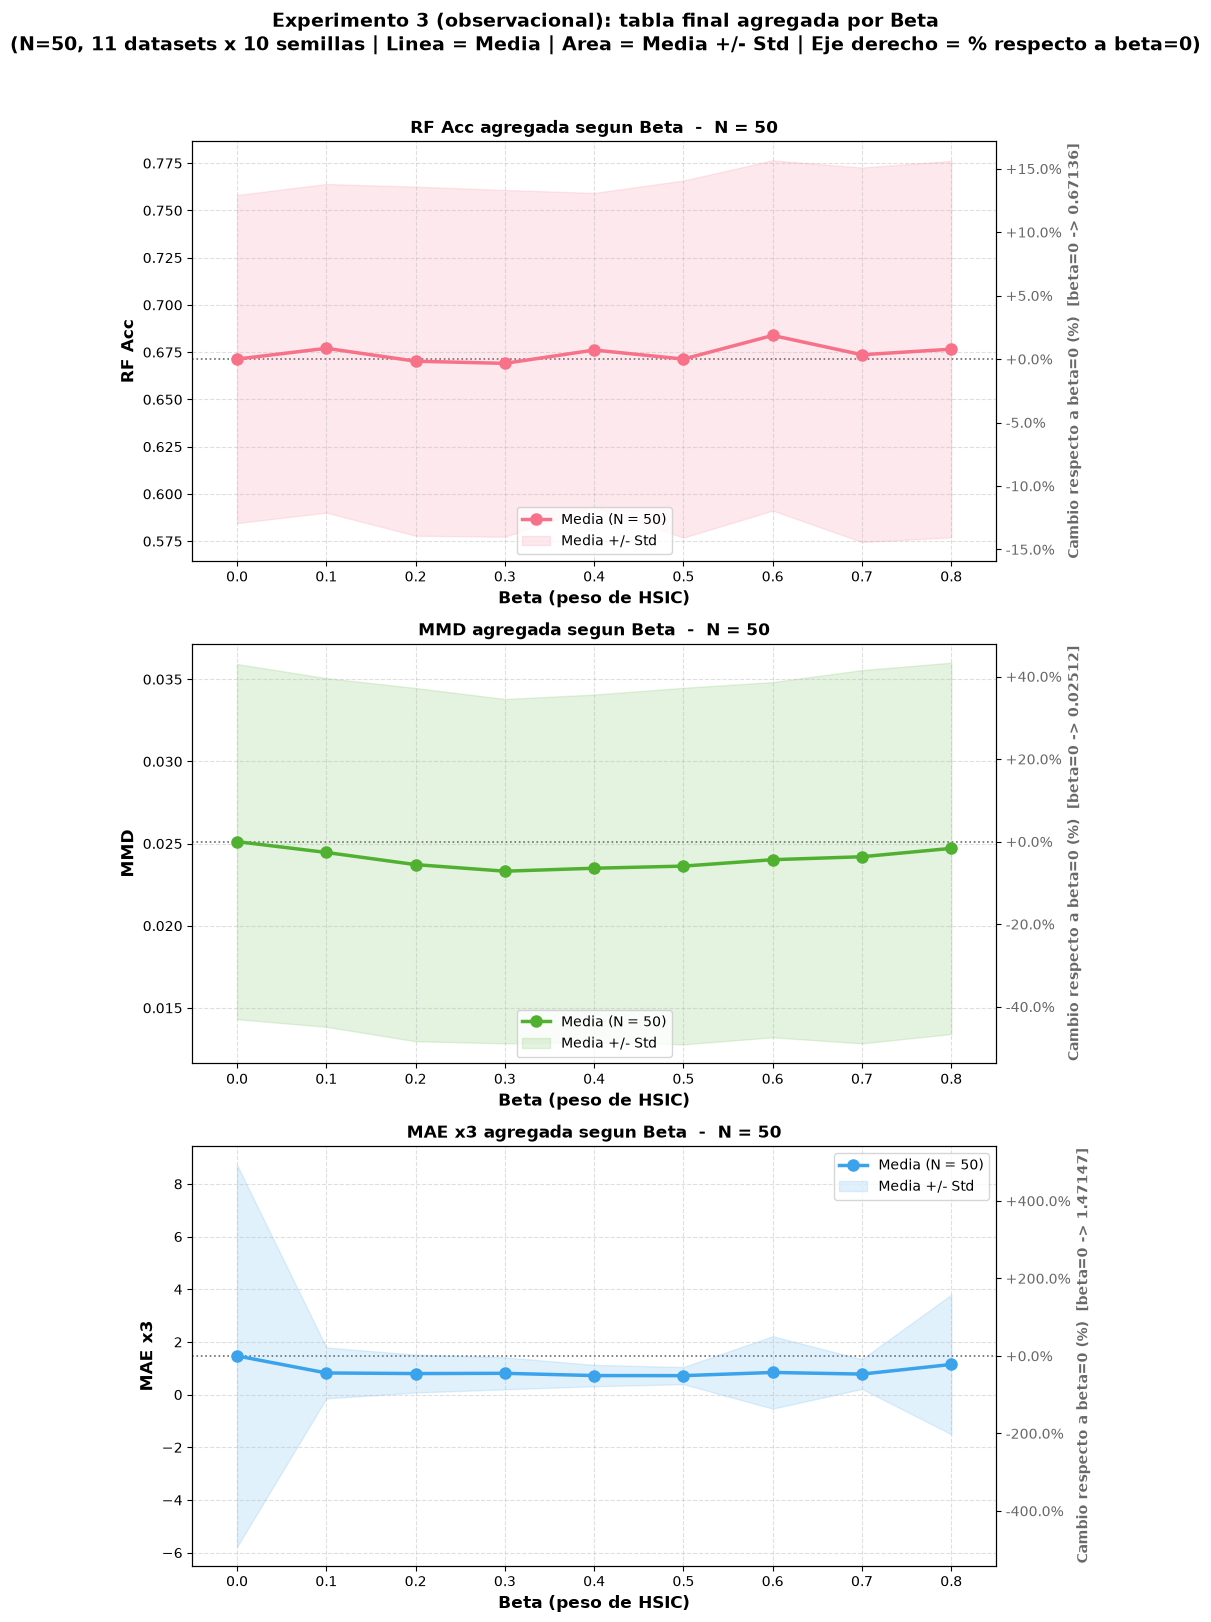

Grafica guardada: plots/bandplot_resumen_final_por_beta_observacional_n_100.png



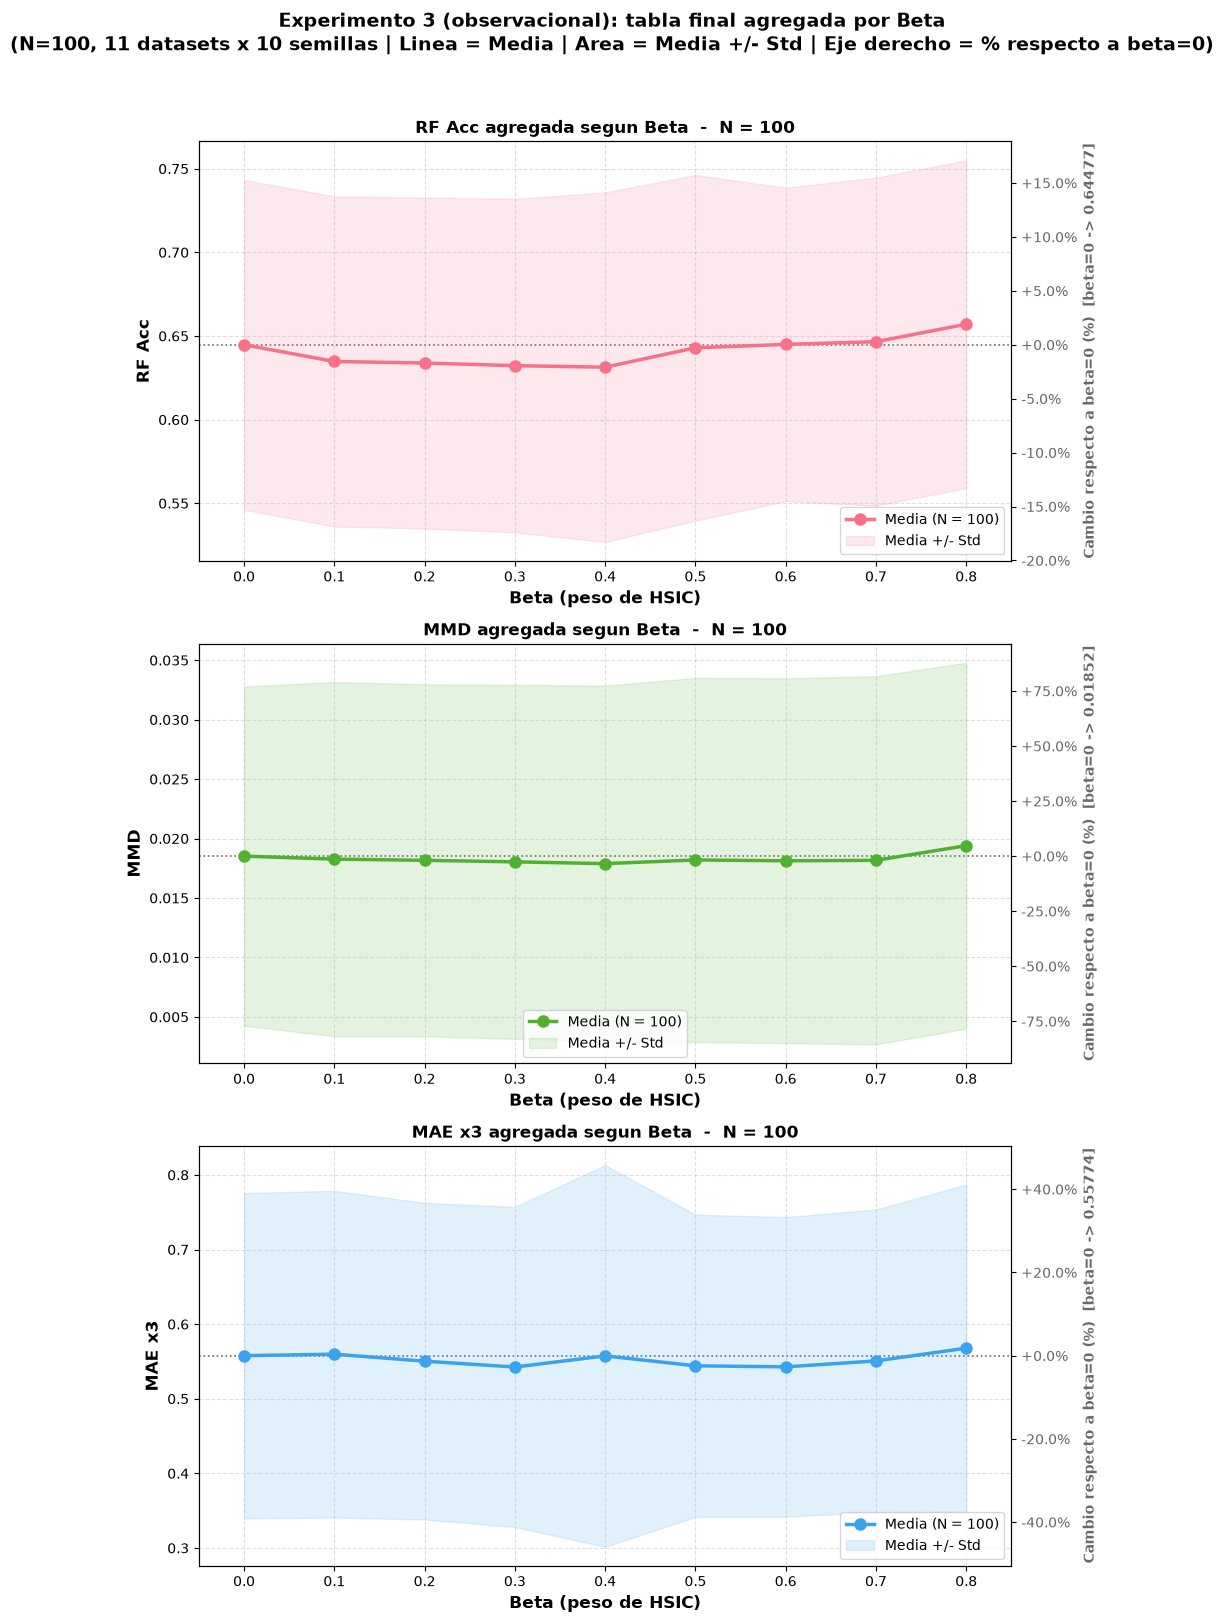


CAMBIO RELATIVO RESPECTO A BETA=0 (%)



,N,Metrica,beta=0.0,beta=0.1,beta=0.2,beta=0.3,beta=0.4,beta=0.5,beta=0.6,beta=0.7,beta=0.8
0,50,RF Acc,+0.00%,+0.85%,-0.17%,-0.34%,+0.71%,+0.00%,+1.86%,+0.34%,+0.78%
1,50,MMD,+0.00%,-2.63%,-5.57%,-7.17%,-6.45%,-5.93%,-4.38%,-3.66%,-1.63%
2,50,MAE x3,+0.00%,-44.03%,-45.59%,-44.94%,-50.77%,-50.95%,-42.72%,-46.92%,-22.11%
3,100,RF Acc,+0.00%,-1.55%,-1.69%,-1.94%,-2.08%,-0.28%,+0.04%,+0.28%,+1.90%
4,100,MMD,+0.00%,-1.35%,-1.89%,-2.59%,-3.40%,-1.73%,-2.11%,-1.89%,+4.75%
5,100,MAE x3,+0.00%,+0.36%,-1.32%,-2.73%,-0.05%,-2.43%,-2.69%,-1.26%,+1.81%


In [5]:
# PASO 9: la tabla final del PASO 8 en forma de grafica, con una figura por cada N y un panel por
# metrica (6 graficas en total). Eje X = beta, linea = media agregada sobre los 11 datasets x 10
# semillas y banda = media +/- desviacion tipica.
# El eje DERECHO es el mismo eje izquierdo reescalado a % de cambio respecto a beta=0: por
# construccion beta=0 marca el 0%, y el resto de betas se leen como su variacion relativa.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACION DE LA TABLA FINAL: MEDIA +/- STD AGREGADA POR BETA")
print("(Una figura por N | Linea = Media | Area sombreada = Media +/- Std)")
print("(Eje derecho = % de cambio respecto a beta=0, que marca el 0%)")
print("="*100 + "\n")

colores_metrica = dict(zip(metricas_experimento, sns.color_palette("husl", len(metricas_experimento))))

if not os.path.exists('plots'):
    os.makedirs('plots')

for n_val in valores_N_experimento:
    # Las 3 metricas se apilan en vertical: una fila por metrica.
    fig, axes = plt.subplots(len(metricas_experimento), 1, figsize=(10, 5.5 * len(metricas_experimento)))
    fig.suptitle('Experimento 3 (observacional): tabla final agregada por Beta\n'
                 f'(N={n_val}, {len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas | '
                 f'Linea = Media | Area = Media +/- Std | Eje derecho = % respecto a beta=0)',
                 fontsize=14, fontweight='bold')

    for ax, metrica in zip(axes, metricas_experimento):
        df_m = df_final_resumen[(df_final_resumen['Metrica'] == metrica) &
                                (df_final_resumen['N'] == n_val)].sort_values('Beta')
        if df_m.empty:
            continue
        x = df_m['Beta'].values
        y_mean = df_m['mean'].values
        y_std = np.nan_to_num(df_m['std'].values)
        color = colores_metrica[metrica]

        ax.plot(x, y_mean, marker='o', linewidth=2.5, markersize=8, color=color, label=f'Media (N = {n_val})')
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color, label='Media +/- Std')

        ax.set_xlabel('Beta (peso de HSIC)', fontsize=12, fontweight='bold')
        ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
        ax.set_title(f'{metrica} agregada segun Beta  -  N = {n_val}', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xticks(valores_beta_candidatos)
        ax.set_xlim(min(valores_beta_candidatos) - 0.05, max(valores_beta_candidatos) + 0.05)
        ax.legend(loc='best', fontsize=10)

        # Eje derecho: el MISMO dato reescalado a % de cambio respecto al valor en beta=0. Se calcula
        # tras dibujar todo, porque necesita los limites definitivos del eje izquierdo.
        es_beta0 = np.isclose(x, 0.0)
        base = float(y_mean[es_beta0][0]) if es_beta0.any() else float('nan')
        if np.isfinite(base) and base != 0.0:
            ax.axhline(base, color='dimgray', linestyle=':', linewidth=1.2, zorder=0)
            lo, hi = ax.get_ylim()
            ax2 = ax.twinx()
            ax2.set_ylim((lo - base) / base * 100.0, (hi - base) / base * 100.0)
            ax2.set_ylabel(f'Cambio respecto a beta=0 (%)  [beta=0 -> {base:.5f}]',
                           fontsize=10, fontweight='bold', color='dimgray')
            ax2.tick_params(axis='y', labelcolor='dimgray')
            ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.1f}%'))
        else:
            print(f"  [aviso] {metrica} (N={n_val}): el valor en beta=0 es {base}, "
                  "no se puede calcular el % de cambio -> panel sin eje derecho.")

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    ruta_plot_final = os.path.join('plots', f'bandplot_resumen_final_por_beta_observacional_n_{n_val}.png')
    plt.savefig(ruta_plot_final, dpi=300, bbox_inches='tight')
    print(f"Grafica guardada: {ruta_plot_final}\n")
    plt.show()


# Tabla de apoyo: los mismos porcentajes que muestra el eje derecho, en numeros.
print("\n" + "="*100)
print("CAMBIO RELATIVO RESPECTO A BETA=0 (%)")
print("="*100 + "\n")
filas_pct = []
for n_val in valores_N_experimento:
    for metrica in metricas_experimento:
        df_m = df_final_resumen[(df_final_resumen['Metrica'] == metrica) &
                                (df_final_resumen['N'] == n_val)].sort_values('Beta')
        if df_m.empty:
            continue
        base_row = df_m[np.isclose(df_m['Beta'], 0.0)]
        if base_row.empty or float(base_row['mean'].iloc[0]) == 0.0:
            continue
        base = float(base_row['mean'].iloc[0])
        fila = {'N': n_val, 'Metrica': metrica}
        for _, r in df_m.iterrows():
            fila[f"beta={r['Beta']}"] = f"{(r['mean'] - base) / base * 100.0:+.2f}%"
        filas_pct.append(fila)

df_pct = pd.DataFrame(filas_pct)
display(df_pct)


In [6]:
# PASO 10: entrenamiento y evaluacion DBCM (mismos datasets, semillas y N que el KAN).
# DBCM no tiene termino HSIC (no depende de beta), asi que solo se entrena una vez por
# combinacion (dataset, semilla, N): 11 datasets x 10 semillas x 2 N = 220 runs.
# Igual que en notebooks/alejandro/paper_plots.ipynb (seccion CONTINUOUS EXPERIMENT) y en
# notebooks/Experimento1/Observacional/Ruido_ Aditivo_Gausiano.ipynb (PASO 8, causal flow como
# baseline), solo se calculan metricas OBSERVACIONALES agnosticas al modelo (MMD, RF Acc): DBCM
# es un modelo generativo por difusion sin una funcion de prediccion puntual f(padres) por nodo,
# asi que no existe un "MAE x3" comparable al residuo (Y - f(X)) que usa el KAN.
# Misma logica de reanudacion que el PASO 2b del KAN (checkpoint por dataset, CSV propio), pero
# la clave de un run es solo (Dataset, Seed, N) porque DBCM no tiene beta.
from copy import deepcopy

from dowhy import gcm
from src.models.factory import create_model_from_graph

# Hiperparametros fijos (sin grid search, igual que base_kan_params): los valores mas seleccionados por la busqueda en rejilla DEFAULT_DBCM_PARAMS de runnables/run_continuous_benchmark.py.
base_dbcm_params = {
    'hidden_dim': 128,
    'lr': 1e-3,
    'weight_decay': 0.001,
    'batch_size': 32,
    'num_epochs': 500,
    'use_gpu_if_available': False,
    'verbose': False,
}

def clave_run_baseline(dataset, seed, n):
    """Identificador de un run sin beta (DBCM/Flow). Sirve para no reentrenar lo que ya esta en el CSV."""
    return (str(dataset), int(seed), int(n))

ruta_dbcm = os.path.join(carpeta_tablas, "dbcm_datasets_sinteticos_observacional.csv")
if os.path.exists(ruta_dbcm):
    df_dbcm_previo = pd.read_csv(ruta_dbcm)
    runs_hechos_dbcm = {clave_run_baseline(r.Dataset, r.Seed, r.N) for r in df_dbcm_previo.itertuples(index=False)}
    print(f"Reanudando DBCM desde {ruta_dbcm}: {len(df_dbcm_previo)} runs ya calculados -> no se reentrenan.")
else:
    df_dbcm_previo = pd.DataFrame()
    runs_hechos_dbcm = set()
    print("No hay CSV previo de DBCM: se entrena el barrido completo desde cero.")

registros_dbcm = []
t_inicio_dbcm = time.time()

def guardar_checkpoint_dbcm():
    """Vuelca a CSV lo previo + lo nuevo. Permite interrumpir y reanudar sin perder trabajo."""
    if not registros_dbcm:
        return
    df_ckpt = pd.concat([df_dbcm_previo, pd.DataFrame(registros_dbcm)], ignore_index=True)
    df_ckpt = df_ckpt.sort_values(by=['Dataset', 'N', 'Seed'])
    df_ckpt.to_csv(ruta_dbcm, index=False)

for dataset in datasets_evaluados:
    print("\n" + "#"*70)
    print(f"[DBCM] DATASET: {dataset}")
    print("#"*70)

    factual_eval_d, _, graph_ds, _ = graph_data(name=dataset).generate(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO)
    var_names = list(factual_eval_d.columns)
    datos_reales_test = factual_eval_d[var_names].to_numpy()
    num_muestras_eval = len(factual_eval_d)

    for experiment_id, seed in enumerate(semillas_experimento, start=1):
        for N_actual in valores_N_experimento:
            if clave_run_baseline(dataset, seed, N_actual) in runs_hechos_dbcm:
                continue

            factual_train_d, _, _, _ = graph_data(name=dataset).generate(num_samples=N_actual, seed=int(seed))

            print(f" -> [DBCM] {dataset} | semilla={seed} | N={N_actual}")
            fila = {'Dataset': dataset, 'Experiment': experiment_id, 'Seed': int(seed), 'N': N_actual}

            try:
                model_dbcm = create_model_from_graph(graph_ds, model="dbcm", params=deepcopy(base_dbcm_params))
                gcm.fit(model_dbcm, data=factual_train_d)

                datos_gen = gcm.draw_samples(model_dbcm, num_samples=num_muestras_eval)[var_names].to_numpy()
                fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en DBCM] {dataset} | N={N_actual} | semilla={seed}: {e}")

            registros_dbcm.append(fila)

    # Checkpoint tras cada dataset: si se interrumpe la ejecucion, al relanzarla se reanuda aqui.
    guardar_checkpoint_dbcm()

df_nuevos_dbcm = pd.DataFrame(registros_dbcm)
df_dbcm = pd.concat([df_dbcm_previo, df_nuevos_dbcm], ignore_index=True) if len(df_dbcm_previo) else df_nuevos_dbcm
df_dbcm = df_dbcm.sort_values(by=['Dataset', 'N', 'Seed']).reset_index(drop=True)

print(f"\n--- DBCM FINALIZADO ---")
print(f"    {len(df_dbcm)} runs en total | {len(df_nuevos_dbcm)} entrenados ahora "
      f"| {len(df_dbcm_previo)} reutilizados | {time.time() - t_inicio_dbcm:.0f} s")
display(df_dbcm)

df_dbcm.to_csv(ruta_dbcm, index=False)
print(f"Tabla DBCM guardada en: {ruta_dbcm}")

No hay CSV previo de DBCM: se entrena el barrido completo desde cero.

######################################################################
[DBCM] DATASET: 3-chain-linear
######################################################################
 -> [DBCM] 3-chain-linear | semilla=42 | N=50


Fitting causal mechanism of node x3: 100%|██████████| 3/3 [00:06<00:00,  2.10s/it]


 -> [DBCM] 3-chain-linear | semilla=42 | N=100


Fitting causal mechanism of node x3: 100%|██████████| 3/3 [00:08<00:00,  2.78s/it]


 -> [DBCM] 3-chain-linear | semilla=43 | N=50


...

 -> [DBCM] triangle-non-linear | semilla=51 | N=100


Fitting causal mechanism of node x3: 100%|██████████| 3/3 [00:06<00:00,  2.13s/it]



--- DBCM FINALIZADO ---
    220 runs en total | 220 entrenados ahora | 0 reutilizados | 1765 s


,Dataset,Experiment,Seed,N,MMD,RF Acc
0,3-chain-linear,1,42,50,0.02534,0.650
1,3-chain-linear,2,43,50,0.01602,0.750
2,3-chain-linear,3,44,50,0.04348,0.625
3,3-chain-linear,4,45,50,0.01665,0.675
4,3-chain-linear,5,46,50,0.02532,0.725
...,...,...,...,...,...,...
215,triangle-non-linear,6,47,100,0.01445,0.600
216,triangle-non-linear,7,48,100,0.01556,0.600
217,triangle-non-linear,8,49,100,0.01959,0.625
218,triangle-non-linear,9,50,100,0.02843,0.700


Tabla DBCM guardada en: tablas/dbcm_datasets_sinteticos_observacional.csv


In [7]:
# PASO 11: entrenamiento y evaluacion Causal Flow (mismos datasets, semillas y N que el KAN).
# Igual que DBCM en el PASO 10: Flow tampoco tiene termino HSIC (no depende de beta), asi que
# se entrena una unica vez por combinacion (dataset, semilla, N) -> 220 runs. Solo se calculan
# MMD y RF Acc: el flow modela la densidad conjunta directamente (no tiene ecuaciones
# estructurales por nodo ni residuos explicitos), tal y como ya se documenta en
# notebooks/Experimento1/Observacional/Ruido_ Aditivo_Gausiano.ipynb (PASO 8).
# Misma logica de reanudacion y checkpoint que el PASO 10 (clave_run_baseline, sin beta).
from src.models.flow import causalflow_model, default_params as default_flow_params

# Hiperparametros fijos (sin grid search, igual que base_dbcm_params): los valores mas seleccionados por la busqueda en rejilla DEFAULT_FLOW_PARAMS de runnables/run_continuous_benchmark.py sobre los 11 datasets continuos.
base_flow_params = deepcopy(default_flow_params)
base_flow_params['flow_type'] = 'CausalNSF'        # elegido en 10/11 datasets
base_flow_params['hidden_dims'] = (32, 32)         # elegido en 6/11 datasets
base_flow_params['base_lr'] = 1e-3                 # elegido en 6/11 datasets
base_flow_params['scheduler'] = 'plateau'          # elegido en 7/11 datasets
base_flow_params['bins'] = 8                       # elegido en 5/11 datasets (empatado con bins=4)
base_flow_params['max_epochs'] = 300               # no buscado en la rejilla (fijo a 1000): recortado por tiempo
base_flow_params['early_stopping_patience'] = 30   # no buscado en la rejilla (fijo a 30): recortado por tiempo

ruta_flow = os.path.join(carpeta_tablas, "flow_datasets_sinteticos_observacional.csv")
if os.path.exists(ruta_flow):
    df_flow_previo = pd.read_csv(ruta_flow)
    runs_hechos_flow = {clave_run_baseline(r.Dataset, r.Seed, r.N) for r in df_flow_previo.itertuples(index=False)}
    print(f"Reanudando Flow desde {ruta_flow}: {len(df_flow_previo)} runs ya calculados -> no se reentrenan.")
else:
    df_flow_previo = pd.DataFrame()
    runs_hechos_flow = set()
    print("No hay CSV previo de Flow: se entrena el barrido completo desde cero.")

registros_flow = []
t_inicio_flow = time.time()

def guardar_checkpoint_flow():
    """Vuelca a CSV lo previo + lo nuevo. Permite interrumpir y reanudar sin perder trabajo."""
    if not registros_flow:
        return
    df_ckpt = pd.concat([df_flow_previo, pd.DataFrame(registros_flow)], ignore_index=True)
    df_ckpt = df_ckpt.sort_values(by=['Dataset', 'N', 'Seed'])
    df_ckpt.to_csv(ruta_flow, index=False)

for dataset in datasets_evaluados:
    print("\n" + "#"*70)
    print(f"[FLOW] DATASET: {dataset}")
    print("#"*70)

    factual_eval_d, _, graph_ds, _ = graph_data(name=dataset).generate(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO)
    var_names = list(factual_eval_d.columns)
    datos_reales_test = factual_eval_d[var_names].to_numpy()
    num_muestras_eval = len(factual_eval_d)

    for experiment_id, seed in enumerate(semillas_experimento, start=1):
        for N_actual in valores_N_experimento:
            if clave_run_baseline(dataset, seed, N_actual) in runs_hechos_flow:
                continue

            factual_train_d, _, _, _ = graph_data(name=dataset).generate(num_samples=N_actual, seed=int(seed))

            print(f" -> [FLOW] {dataset} | semilla={seed} | N={N_actual}")
            fila = {'Dataset': dataset, 'Experiment': experiment_id, 'Seed': int(seed), 'N': N_actual}

            try:
                model_flow = causalflow_model(graph_ds, deepcopy(base_flow_params))
                model_flow.fit(factual_train_d)

                datos_gen = model_flow.draw_samples(num_samples=num_muestras_eval)[var_names].to_numpy()
                fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en Flow] {dataset} | N={N_actual} | semilla={seed}: {e}")

            registros_flow.append(fila)

    # Checkpoint tras cada dataset: si se interrumpe la ejecucion, al relanzarla se reanuda aqui.
    guardar_checkpoint_flow()

df_nuevos_flow = pd.DataFrame(registros_flow)
df_flow = pd.concat([df_flow_previo, df_nuevos_flow], ignore_index=True) if len(df_flow_previo) else df_nuevos_flow
df_flow = df_flow.sort_values(by=['Dataset', 'N', 'Seed']).reset_index(drop=True)

print(f"\n--- FLOW FINALIZADO ---")
print(f"    {len(df_flow)} runs en total | {len(df_nuevos_flow)} entrenados ahora "
      f"| {len(df_flow_previo)} reutilizados | {time.time() - t_inicio_flow:.0f} s")
display(df_flow)

df_flow.to_csv(ruta_flow, index=False)
print(f"Tabla Flow guardada en: {ruta_flow}")

No hay CSV previo de Flow: se entrena el barrido completo desde cero.

######################################################################
[FLOW] DATASET: 3-chain-linear
######################################################################
 -> [FLOW] 3-chain-linear | semilla=42 | N=50


 74%|███████▍  | 222/300 [00:01<00:00, 123.91it/s]

Early stopping at epoch 223


 -> [FLOW] 3-chain-linear | semilla=42 | N=100


100%|██████████| 300/300 [00:01<00:00, 167.47it/s]


...

Early stopping at epoch 163
 -> [FLOW] triangle-non-linear | semilla=51 | N=100


 72%|███████▏  | 216/300 [00:01<00:00, 127.78it/s]


Early stopping at epoch 217

--- FLOW FINALIZADO ---
    220 runs en total | 220 entrenados ahora | 0 reutilizados | 264 s


,Dataset,Experiment,Seed,N,MMD,RF Acc
0,3-chain-linear,1,42,50,0.00883,0.675
1,3-chain-linear,2,43,50,0.01315,0.675
2,3-chain-linear,3,44,50,0.01380,0.600
3,3-chain-linear,4,45,50,0.01503,0.775
4,3-chain-linear,5,46,50,0.01085,0.675
...,...,...,...,...,...,...
215,triangle-non-linear,6,47,100,0.01806,0.625
216,triangle-non-linear,7,48,100,0.01125,0.625
217,triangle-non-linear,8,49,100,0.02315,0.650
218,triangle-non-linear,9,50,100,0.02708,0.650


Tabla Flow guardada en: tablas/flow_datasets_sinteticos_observacional.csv


In [8]:
# PASO 12: resumen media +/- std de DBCM y Flow, agregando los 11 datasets x 10 semillas x 2 N
# (220 runs cada uno). No hay desglose por beta porque ninguno de los dos depende de ella.
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA +/- DESVIACION TIPICA (DBCM Y FLOW)")
print("(agregado sobre 11 datasets x 10 semillas x 2 N -> 220 runs por modelo)")
print("="*100)

resumen_dbcm = pd.DataFrame({
    'mean': df_dbcm[['MMD', 'RF Acc']].mean(),
    'std': df_dbcm[['MMD', 'RF Acc']].std(),
}).round(5)
resumen_flow = pd.DataFrame({
    'mean': df_flow[['MMD', 'RF Acc']].mean(),
    'std': df_flow[['MMD', 'RF Acc']].std(),
}).round(5)

print("\nDBCM:")
display(resumen_dbcm)
print("\nCausal Flow:")
display(resumen_flow)

ruta_resumen_baselines = os.path.join("tablas", "resumen_dbcm_flow_observacional.csv")
pd.concat(
    {'DBCM': resumen_dbcm, 'CausalFlow': resumen_flow}, names=['Modelo', 'Metrica']
).to_csv(ruta_resumen_baselines)
print(f"\nTabla resumen DBCM/Flow guardada en: {ruta_resumen_baselines}")


TABLA RESUMEN: MEDIA +/- DESVIACION TIPICA (DBCM Y FLOW)
(agregado sobre 11 datasets x 10 semillas x 2 N -> 220 runs por modelo)

DBCM:


,mean,std
MMD,0.02002,0.00949
RF Acc,0.66773,0.08188



Causal Flow:


,mean,std
MMD,0.01783,0.00923
RF Acc,0.63227,0.07397



Tabla resumen DBCM/Flow guardada en: tablas/resumen_dbcm_flow_observacional.csv


Grafica guardada: plots/comparativa_kan_dbcm_flow_observacional.png


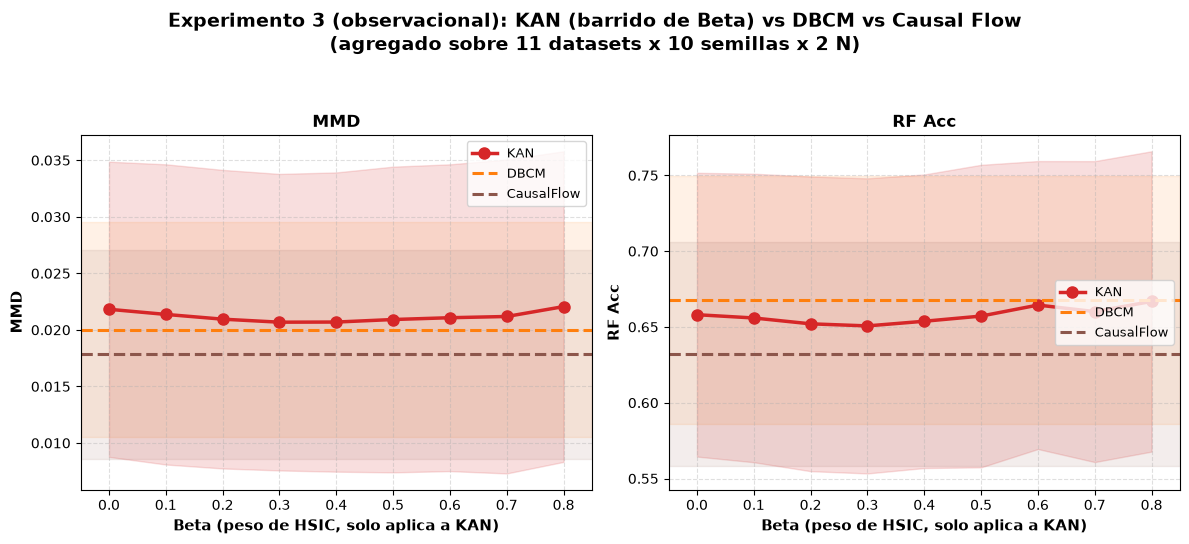

In [9]:
# PASO 13: grafica final comparativa KAN (barrido de Beta) vs DBCM vs Causal Flow.
# Una unica figura con 2 paneles: MMD y RF Acc, las dos metricas comparables entre los 3 modelos.
# KAN se dibuja como linea+banda a traves de sus betas (agregando los 2 N y los 11 datasets x 10
# semillas = 220 runs/beta, igual que el PASO 9). DBCM y Flow no tienen beta, asi que se dibujan
# como una linea horizontal de referencia (con banda +/- std) a lo largo del mismo eje X,
# agregando tambien sus 220 runs.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle('Experimento 3 (observacional): KAN (barrido de Beta) vs DBCM vs Causal Flow\n'
             f'(agregado sobre {len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas x {len(valores_N_experimento)} N)',
             fontsize=14, fontweight='bold')

metricas_comunes = ['MMD', 'RF Acc']  # Comparables entre los 3 modelos
x_beta = np.array(valores_beta_candidatos)
x_min, x_max = x_beta.min() - 0.05, x_beta.max() + 0.05
colores_modelo = {'KAN': 'tab:red', 'DBCM': 'tab:orange', 'CausalFlow': 'tab:brown'}

for ax, metrica in zip(axes, metricas_comunes):
    # KAN: media +/- std por beta (agrega N, datasets y semillas)
    y_mean_kan = df_final.groupby('Beta')[metrica].mean().reindex(valores_beta_candidatos).values
    y_std_kan = df_final.groupby('Beta')[metrica].std().reindex(valores_beta_candidatos).values
    ax.plot(x_beta, y_mean_kan, marker='o', linewidth=2.5, markersize=8, color=colores_modelo['KAN'], label='KAN')
    ax.fill_between(x_beta, y_mean_kan - y_std_kan, y_mean_kan + y_std_kan, alpha=0.15, color=colores_modelo['KAN'])

    # DBCM y Flow: sin beta -> linea horizontal de referencia con banda +/- std
    for df_baseline, nombre in [(df_dbcm, 'DBCM'), (df_flow, 'CausalFlow')]:
        y_mean = df_baseline[metrica].mean()
        y_std = df_baseline[metrica].std()
        color = colores_modelo[nombre]
        ax.hlines(y_mean, x_min, x_max, linestyles='--', linewidth=2.2, color=color, label=nombre)
        ax.fill_between([x_min, x_max], [y_mean - y_std] * 2, [y_mean + y_std] * 2, alpha=0.1, color=color)

    ax.set_xlabel('Beta (peso de HSIC, solo aplica a KAN)', fontsize=11, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=11, fontweight='bold')
    ax.set_title(f'{metrica}', fontsize=12, fontweight='bold')
    ax.set_xticks(valores_beta_candidatos)
    ax.set_xlim(x_min, x_max)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.93])

if not os.path.exists('plots'):
    os.makedirs('plots')
ruta_plot_comp = os.path.join('plots', 'comparativa_kan_dbcm_flow_observacional.png')
plt.savefig(ruta_plot_comp, dpi=300, bbox_inches='tight')
print(f"Grafica guardada: {ruta_plot_comp}")
plt.show()



MMD:
  KAN beta=0.0   n= 220 | mediana=0.01865 | media=0.02182 | std=0.01305
  KAN beta=0.2   n= 220 | mediana=0.01728 | media=0.02095 | std=0.01320
  KAN beta=0.4   n= 220 | mediana=0.01709 | media=0.02069 | std=0.01323
  KAN beta=0.6   n= 220 | mediana=0.01726 | media=0.02107 | std=0.01356
  DBCM           n= 220 | mediana=0.01770 | media=0.02002 | std=0.00949
  CausalFlow     n= 220 | mediana=0.01520 | media=0.01783 | std=0.00923

RF Acc:
  KAN beta=0.0   n= 220 | mediana=0.65000 | media=0.65807 | std=0.09360
  KAN beta=0.2   n= 220 | mediana=0.65000 | media=0.65205 | std=0.09720
  KAN beta=0.4   n= 220 | mediana=0.65000 | media=0.65375 | std=0.09684
  KAN beta=0.6   n= 220 | mediana=0.65000 | media=0.66443 | std=0.09499
  DBCM           n= 220 | mediana=0.67500 | media=0.66773 | std=0.08188
  CausalFlow     n= 220 | mediana=0.62500 | media=0.63227 | std=0.07397

Grafica guardada: plots/boxplot_kan_dbcm_flow_observacional.png


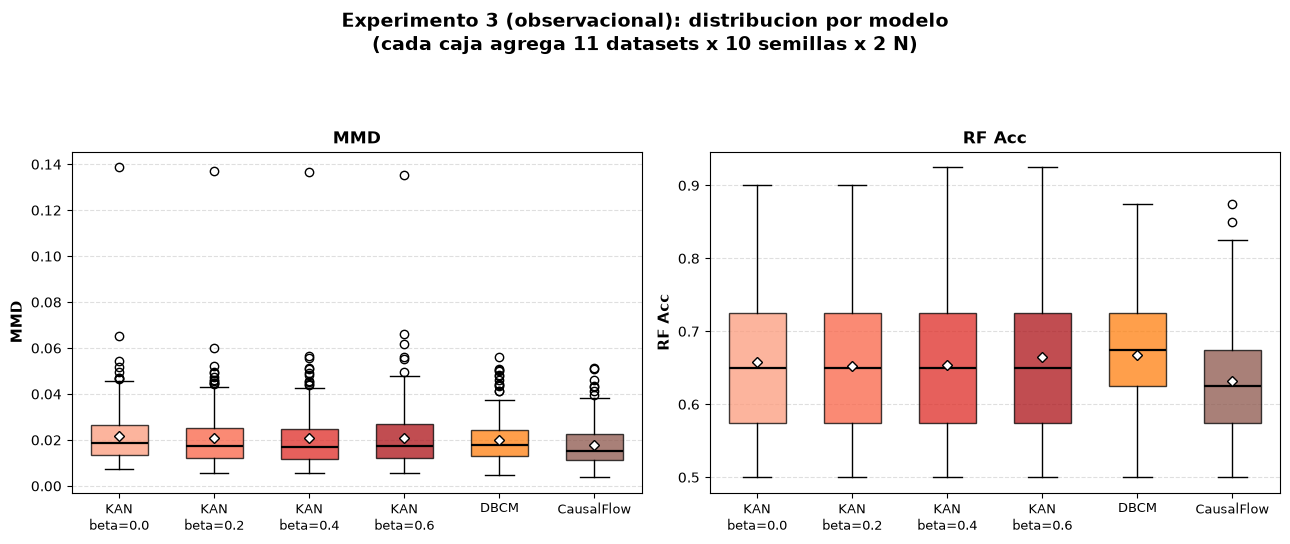

In [10]:
# PASO 14: la misma informacion del PASO 13, pero como boxplot (distribucion completa, no solo media +/- std).
# Dos paneles (MMD y RF Acc) con una caja por modelo: KAN con beta = 0.0, 0.2, 0.4 y 0.6 (cada caja agrega
# sus 11 datasets x 10 semillas x 2 N = 220 runs) mas DBCM y Causal Flow (220 runs cada uno).
betas_boxplot = [0.0, 0.2, 0.4, 0.6]
metricas_boxplot = ['MMD', 'RF Acc']
colores_modelo = {'KAN': 'tab:red', 'DBCM': 'tab:orange', 'CausalFlow': 'tab:brown'}

etiquetas_plot = [f'KAN\nbeta={b}' for b in betas_boxplot] + ['DBCM', 'CausalFlow']
etiquetas_txt = [f'KAN beta={b}' for b in betas_boxplot] + ['DBCM', 'CausalFlow']
colores_caja = [plt.cm.Reds(v) for v in np.linspace(0.35, 0.85, len(betas_boxplot))]
colores_caja += [colores_modelo['DBCM'], colores_modelo['CausalFlow']]

fig, axes = plt.subplots(1, len(metricas_boxplot), figsize=(13, 5.5))
fig.suptitle('Experimento 3 (observacional): distribucion por modelo\n'
             f'(cada caja agrega {len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas x {len(valores_N_experimento)} N)',
             fontsize=14, fontweight='bold')

for ax, metrica in zip(axes, metricas_boxplot):
    # Una caja por beta de KAN (np.isclose para no depender de la precision del float leido del CSV)
    datos_caja = [df_final.loc[np.isclose(df_final['Beta'], b), metrica].dropna().values for b in betas_boxplot]
    datos_caja += [df_dbcm[metrica].dropna().values, df_flow[metrica].dropna().values]

    bp = ax.boxplot(datos_caja, patch_artist=True, showmeans=True, widths=0.6,
                    medianprops=dict(color='black', linewidth=1.6),
                    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=5))
    for parche, color in zip(bp['boxes'], colores_caja):
        parche.set_facecolor(color)
        parche.set_alpha(0.75)

    ax.set_xticks(range(1, len(etiquetas_plot) + 1))
    ax.set_xticklabels(etiquetas_plot, fontsize=9)
    ax.set_ylabel(metrica, fontsize=11, fontweight='bold')
    ax.set_title(f'{metrica}', fontsize=12, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    print(f"\n{metrica}:")
    for etiqueta, valores in zip(etiquetas_txt, datos_caja):
        print(f"  {etiqueta:14s} n={len(valores):4d} | mediana={np.median(valores):.5f} | media={np.mean(valores):.5f} | std={np.std(valores, ddof=1):.5f}")

plt.tight_layout(rect=[0, 0, 1, 0.9])

if not os.path.exists('plots'):
    os.makedirs('plots')
ruta_plot_box = os.path.join('plots', 'boxplot_kan_dbcm_flow_observacional.png')
plt.savefig(ruta_plot_box, dpi=300, bbox_inches='tight')
print(f"\nGrafica guardada: {ruta_plot_box}")
plt.show()
